In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns

from pathlib import Path
from MITRotor import IEA10MW
from wrf_io import postproc

In [2]:
rotor = IEA10MW()

nElements = 30
nSections = 160

In [3]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [4]:
wrfles_bem = []
# wrfles_wind = []
wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/uniform_test/new_testing/U07_matching/U07_lite.npz')))
# wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/uniform_test/new_testing/U07/U07_lite.npz')))

In [5]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/uniform_test/new_testing/U07_matching/input_sounding")
# file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/uniform_test/new_testing/U07/input_sounding")

data = extract_columns(file_list)

t = np.linspace(0,2*np.pi,nSections)
r = np.linspace(0,1,nElements)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles_bem[0]['diameter']/2 + 378

In [6]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [7]:
def annulus_average(theta, X):

    dtheta = np.gradient(theta)
    weights = dtheta / np.sum(dtheta)
    X_azim = np.sum(X * weights, axis=1)

    return X_azim

def annulus_average_0(theta, X):

    dtheta = np.gradient(theta)
    weights = dtheta / np.sum(dtheta)
    X_azim = np.sum(X * weights, axis=0)

    return X_azim

def rotor_average(r, X):
    # Takes annulus average quantities and performs rotor average

    dr = np.gradient(r)
    area_elements = 2 * np.pi * r * dr  # differential area for annular rings
    integrand = X * area_elements

    # A = np.pi * (r[-1]**2 - r[0]**2)  # total area of annulus from R1 to R2
    A = np.pi * (1**2 - (2.4/99.5)**2)  # total area of annulus from R1 to R2

    X_rotor =  np.sum(integrand) / A

    return X_rotor

/tmp/ipykernel_71372/420516385.py:84: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=110, edgecolor='none',color=colors[count],alpha=0.5, zorder = count + 2)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


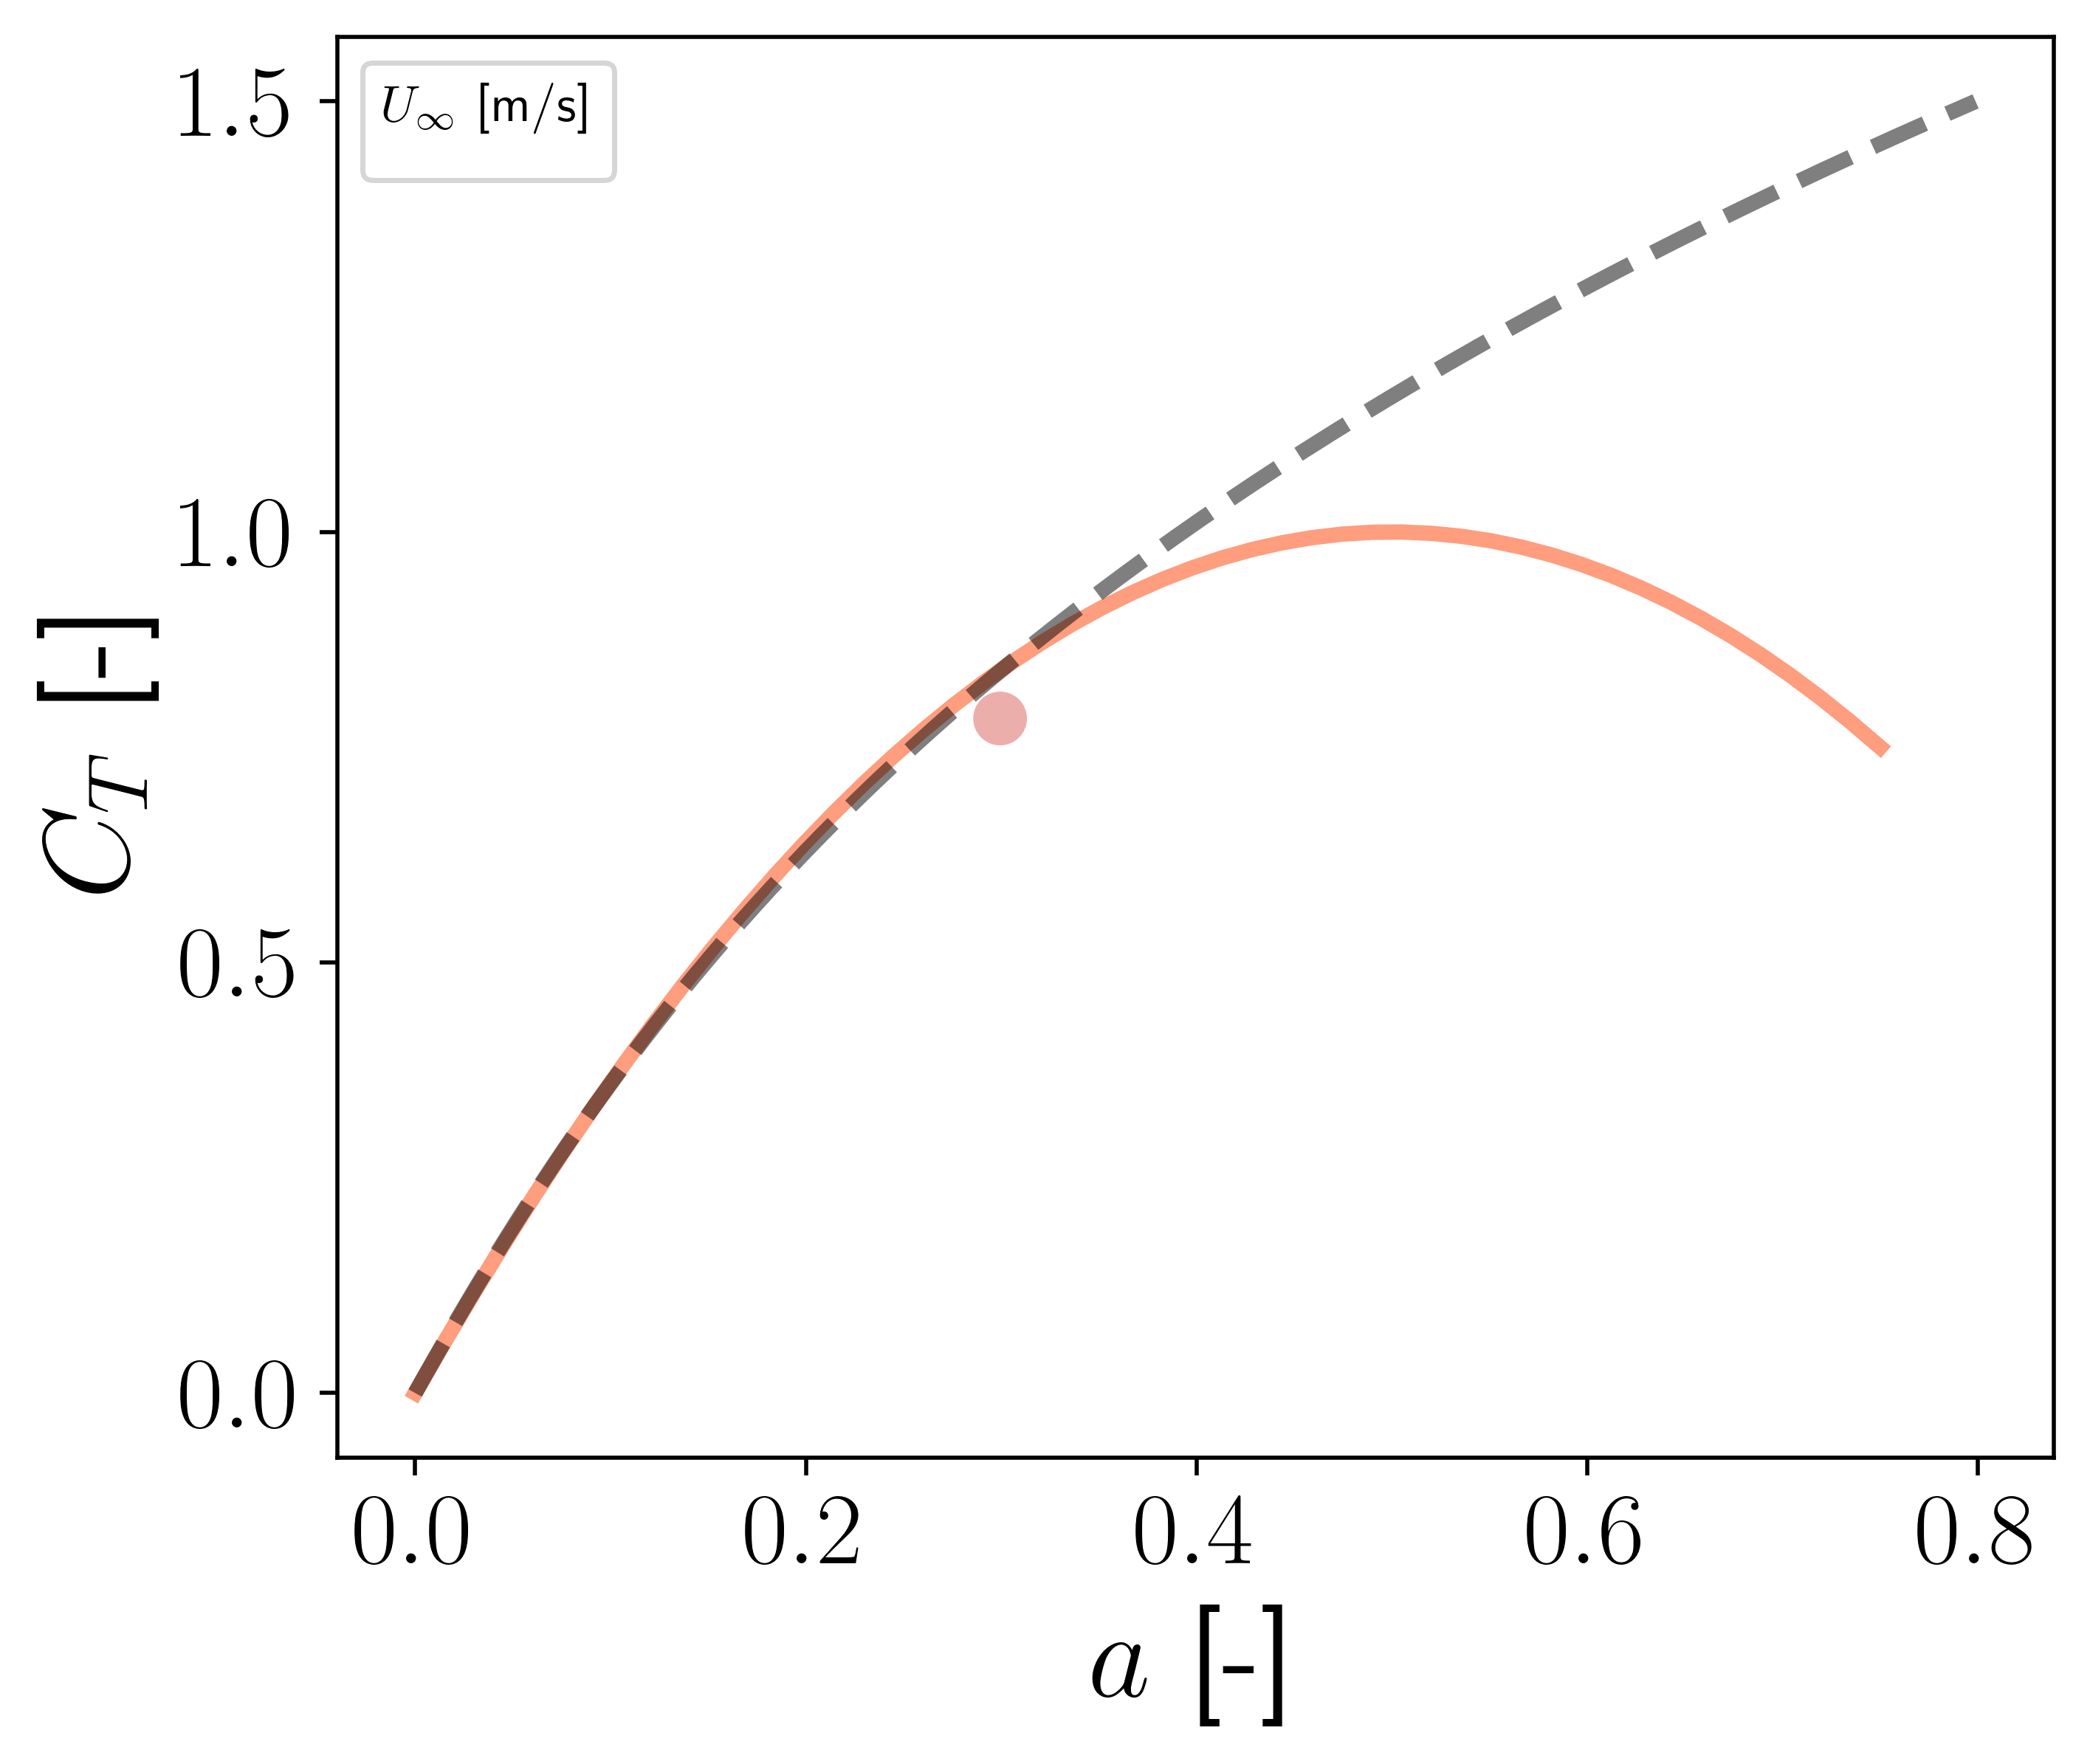

In [8]:
Nelm = 30
Nsct = 160

casenames = ['U07_matching']

ind_rotor = np.zeros_like(casenames, dtype=float)
ct_rotor  = np.zeros_like(casenames, dtype=float)

ind_loc = np.zeros((nElements, nSections, len(casenames)))
ct_loc  = np.zeros((nElements, nSections, len(casenames)))

colors = sns.color_palette("hls", 5)

fig, ax = plt.subplots(figsize=(6, 5))

casenmes = ['U07_matching']

for count,case in enumerate(casenames):
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    u_inf = u_func(Y)
    v_inf = v_func(Y)

    r = wrfles_bem[count]['rOverR'] * rotor.R

    # Compute induction
    # ind = 1 - np.mean(wrfles_bem[count]['shapiroM'][-1] * wrfles_bem[count]['v1'],axis=0) / 7
    ind = 1 - np.mean(wrfles_bem[count]['v1'],axis=0) / 7
    # ind = 1 - rotor_average(wrfles_bem[count]['rOverR'], annulus_average(np.linspace(0, 2*np.pi, nSections), np.mean(wrfles_bem[count]['shapiroM'][-1] * wrfles_bem[count]['v1'],axis=0)))/7

    phi = np.deg2rad(np.mean(wrfles_bem[count]['phi'], axis=0))
    Cl = np.mean(wrfles_bem[count]['cl'], axis=0)
    Cd = np.mean(wrfles_bem[count]['cd'], axis=0)

    r =  (np.ones_like(Cd.T) * r).T

    # sigma = [0.63301,0.53955,0.44608,0.35262,0.25916,0.16570,0.12249,0.10792,0.09840,0.08889,0.07938,0.06987,0.06035,0.05084,0.04133,0.03518,0.03085,0.02652,0.02358,0.02071,0.01784,0.01597,0.01415,0.01233,0.01051,0.00869,0.00687,0.00505,0.00323,0.00141]
    chord = [4.649118,4.890711,5.132303,5.373896,5.615488,5.857080,5.959029,5.917359,5.658924,5.400488,5.142053,4.883618,4.625183,4.366748,4.108313,3.835882,3.555919,3.275956,3.037851,2.801943,2.566033,2.307137,2.047028,1.786918,1.526808,1.266698,1.006588,0.746478,0.486368,0.226259]

    # chord = (FN / (0.5 * 1.225 * (W*7)**2 * Cax))[:,1]
    sigma = 3 * np.array(chord)/ (2 * np.pi * wrfles_bem[0]['rOverR'] * 99.5)

    sigma =  (np.ones_like(Cd.T) * sigma).T
    chord =  (np.ones_like(ind.T) * chord).T

    # Relative velocity
    W = np.mean(wrfles_bem[count]['vrel'], axis=0) / 7

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma * W**2 * Cax

    rho = 1.225

    W_dim = W * 7

    L = 1/2 * rho * chord * (Cl * W_dim**2)
    D = 1/2 * rho * chord * (Cd * W_dim**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (rotor.R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * (3/Nsct))

    P = np.sum(FT * r * dr * (3/Nsct) * (np.mean(wrfles_bem[count]['omega'], axis=0) * 2 * np.pi / 60))

    ind_loc[:,:,count] = ind
    ct_loc[:,:,count]  = ct

    ct_annular = annulus_average(np.linspace(0, 2*np.pi, nSections), ct)
    ind_annular = annulus_average(np.linspace(0, 2*np.pi, nSections), ind)

    ct_rotor[count]  = rotor_average(wrfles_bem[count]['rOverR'], ct_annular)
    # ct_rotor[count]  = rotor_average(wrfles_bem[count]['rOverR'], ct)

    ind_rotor[count] = rotor_average(wrfles_bem[count]['rOverR'], ind_annular)
    # ind_rotor[count] = ind
    ax.scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=110, edgecolor='none',color=colors[count],alpha=0.5, zorder = count + 2)

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,alpha = 0.5, zorder = 1)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,alpha=0.5,zorder=2)

ax.set_xlabel('$a$ [-]', fontsize=fontsize)
ax.set_ylabel('$C_T$ [-]', fontsize=fontsize)

plt.legend(title='$U_{\infty}$ [m/s]')

plt.show()

In [12]:
[ind_rotor[0], ct_rotor[0]]

[np.float64(0.2994519595473826), np.float64(0.7833299203547336)]

In [9]:
P/1000

np.float64(3014.4177040408904)

In [17]:
chord = [4.649118,4.890711,5.132303,5.373896,5.615488,5.857080,5.959029,5.917359,5.658924,5.400488,5.142053,4.883618,4.625183,4.366748,4.108313,3.835882,3.555919,3.275956,3.037851,2.801943,2.566033,2.307137,2.047028,1.786918,1.526808,1.266698,1.006588,0.746478,0.486368,0.226259]
3 * np.array(chord)/ (2 * np.pi * wrfles_bem[0]['rOverR'] * 99.5)

array([0.55241568, 0.32186664, 0.23356577, 0.18690152, 0.15804291,
       0.13843163, 0.12139203, 0.10591681, 0.09033055, 0.07778802,
       0.06747697, 0.05885052, 0.05152702, 0.04523199, 0.039763  ,
       0.03484034, 0.03042427, 0.02649237, 0.02329007, 0.0204202 ,
       0.01782052, 0.01530216, 0.01299281, 0.01087398, 0.00892304,
       0.00712078, 0.00545085, 0.00389917, 0.00245363, 0.00110369])

In [40]:
(FN / (0.5 * 1.225 * (W*7)**2 * Cax))[:,1]

array([4.64911814, 4.89071115, 5.13230257, 5.37389596, 5.61548771,
       5.85708051, 5.95902834, 5.91735877, 5.65892409, 5.40048826,
       5.14205299, 4.88361773, 4.62518314, 4.36674773, 4.1083129 ,
       3.83588206, 3.55591855, 3.2759558 , 3.03785101, 2.80194284,
       2.56603291, 2.30713716, 2.04702785, 1.78691803, 1.52680799,
       1.26669807, 1.00658801, 0.74647803, 0.48636793, 0.22625899])

In [48]:
sigma = [0.63301,0.53955,0.44608,0.35262,0.25916,0.16570,0.12249,0.10792,0.09840,0.08889,0.07938,0.06987,0.06035,0.05084,0.04133,0.03518,0.03085,0.02652,0.02358,0.02071,0.01784,0.01597,0.01415,0.01233,0.01051,0.00869,0.00687,0.00505,0.00323,0.00141]
chord = [4.649118,4.890711,5.132303,5.373896,5.615488,5.857080,5.959029,5.917359,5.658924,5.400488,5.142053,4.883618,4.625183,4.366748,4.108313,3.835882,3.555919,3.275956,3.037851,2.801943,2.566033,2.307137,2.047028,1.786918,1.526808,1.266698,1.006588,0.746478,0.486368,0.226259]

sigma = np.array(sigma)
annulus_average(wrfles_bem[count]['rOverR'], sigma.T)
# wrfles_bem[count]['rOverR']

AxisError: axis 1 is out of bounds for array of dimension 1

In [63]:
k3 *0.86684876**3 + k2 * 0.86684876**2 + k1 * 0.86684876

0.3147946720727234

In [64]:
wrfles_bem[count]['shapiroM'][0]

array([0.9861922], dtype=float32)

In [124]:
wrfles_bem[0]['rOverR']

array([0.04288751, 0.08042134, 0.11795516, 0.15548898, 0.19302281,
       0.23055663, 0.26809045, 0.30562428, 0.3431581 , 0.38069192,
       0.41822574, 0.45575957, 0.49329339, 0.53082721, 0.56836104,
       0.60589486, 0.64342868, 0.6809625 , 0.71849633, 0.75603015,
       0.79356397, 0.8310978 , 0.86863162, 0.90616544, 0.94369927,
       0.98123309])

In [32]:
rotor.chord_func(wrfles_bem[0]['rOverR'])

array([4.66772551, 4.94646327, 5.22520102, 5.50393878, 5.78267654,
       5.95488659, 5.91741297, 5.619217  , 5.32102104, 5.02282507,
       4.72462911, 4.42643314, 4.12823717, 3.81439031, 3.49135165,
       3.18304662, 2.91081356, 2.63858051, 2.347105  , 2.04698434,
       1.74686367, 1.446743  , 1.14662233, 0.84650167, 0.546381  ,
       0.24626033])

In [62]:
wrfles_bem[0]['rOverR']*0.97

array([0.04160089, 0.0780087 , 0.11441651, 0.15082431, 0.18723212,
       0.22363993, 0.26004774, 0.29645555, 0.33286336, 0.36927116,
       0.40567897, 0.44208678, 0.47849459, 0.5149024 , 0.5513102 ,
       0.58771801, 0.62412582, 0.66053363, 0.69694144, 0.73334925,
       0.76975705, 0.80616486, 0.84257267, 0.87898048, 0.91538829,
       0.9517961 ])

In [61]:
wrfles_bem[0]['rOverR']

array([0.04288751, 0.08042134, 0.11795516, 0.15548898, 0.19302281,
       0.23055663, 0.26809045, 0.30562428, 0.3431581 , 0.38069192,
       0.41822574, 0.45575957, 0.49329339, 0.53082721, 0.56836104,
       0.60589486, 0.64342868, 0.6809625 , 0.71849633, 0.75603015,
       0.79356397, 0.8310978 , 0.86863162, 0.90616544, 0.94369927,
       0.98123309])

In [47]:
np.round(r,3)

array([[ 4.267,  4.267,  4.267, ...,  4.267,  4.267,  4.267],
       [ 8.002,  8.002,  8.002, ...,  8.002,  8.002,  8.002],
       [11.737, 11.737, 11.737, ..., 11.737, 11.737, 11.737],
       ...,
       [90.163, 90.163, 90.163, ..., 90.163, 90.163, 90.163],
       [93.898, 93.898, 93.898, ..., 93.898, 93.898, 93.898],
       [97.633, 97.633, 97.633, ..., 97.633, 97.633, 97.633]],
      shape=(26, 158))

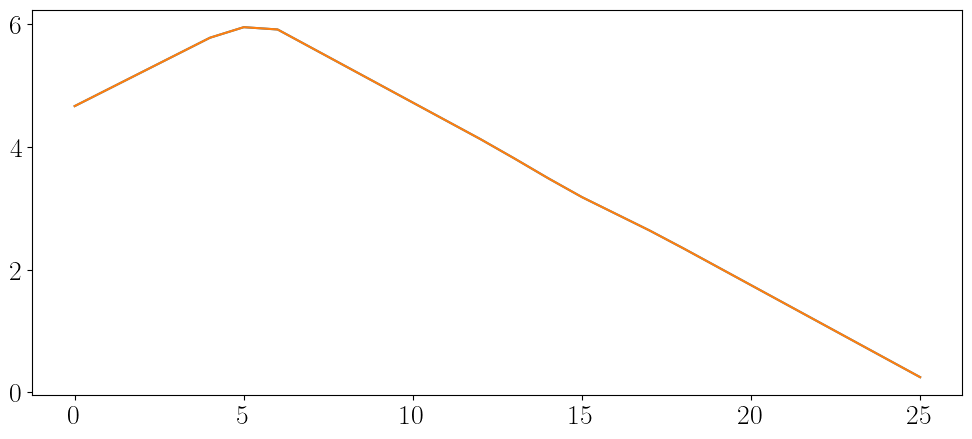

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

chord = [
4.66770,
4.94646,
5.22522,
5.50398,
5.78274,
5.95491,
5.91736,
5.61917,
5.32097,
5.02278,
4.72458,
4.42639,
4.12819,
3.81434,
3.49131,
3.18302,
2.91082,
2.63862,
2.34715,
2.04702,
1.74690,
1.44677,
1.14664,
0.84651,
0.54639,
0.24626 
]

ax.plot(chord, label='case 1')
ax.plot(rotor.chord_func(wrfles_bem[count]['rOverR']), label='case 4')

In [26]:
sigma[:,0]

array([0.52226433, 0.29514794, 0.21257072, 0.16986018, 0.14376026,
       0.12394105, 0.10591682, 0.08822723, 0.07440718, 0.0633124 ,
       0.05420892, 0.04660497, 0.04015806, 0.03448137, 0.02947694,
       0.02520928, 0.02170867, 0.01859396, 0.01567598, 0.01299276,
       0.01056342, 0.00835345, 0.00633446, 0.00448273, 0.00277835,
       0.00120431])

Text(0.5, 1.0, 'Solidity')

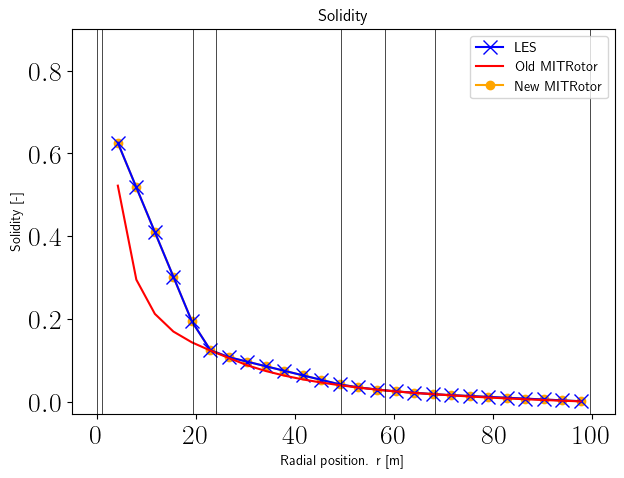

In [307]:
fig, ax = plt.subplots(figsize=(7, 5))

sigma = [
0.625818,
0.517977,
0.410137,
0.302296,
0.194455,
0.124975,
0.107916,
0.09694,
0.085964,
0.074988,
0.064012,
0.053036,
0.04206,
0.034849,
0.029849,
0.02534,
0.022033,
0.018726,
0.016251,
0.014151,
0.012051,
0.009951,
0.007851,
0.00575,
0.00365,
0.00155
    ]

ax.plot(r[:,0], sigma, color='b', markersize = 10, marker='x', label='LES',zorder=2)
ax.plot(r[:,0], rotor.solidity_func(wrfles_bem[count]['rOverR']), color = 'red', label='Old MITRotor')
ax.plot(r[:,0], sol_func(wrfles_bem[count]['rOverR']), color = 'orange', marker='o', label='New MITRotor',zorder=1)
ax.vlines(np.array([0.0, 0.01, 0.195, 0.242, 0.495, 0.585, 0.685, 1.0])*99.5,-1, 1, color='k', linewidth=0.5)
ax.legend()

ax.set_ylim([-0.03, 0.9])

ax.set_xlabel('Radial position. r [m]')
ax.set_ylabel('Solidity [-]')
ax.set_title('Solidity')

In [14]:
rotor.solidity_func(wrfles_bem[count]['rOverR'])

array([0.52226718, 0.29514933, 0.21257117, 0.16986045, 0.14376017,
       0.12394077, 0.10591777, 0.08822797, 0.0744079 , 0.06331297,
       0.05420948, 0.04660542, 0.04015852, 0.03448183, 0.02947729,
       0.02520949, 0.02170862, 0.01859368, 0.01567568, 0.01299253,
       0.0105632 , 0.00835329, 0.00633436, 0.00448269, 0.00277831,
       0.00120432])

In [25]:
3 * rotor.chord_func(wrfles_bem[count]['rOverR']) / (2 * np.pi * np.maximum(wrfles_bem[count]['rOverR'], 0.0001) * rotor.R),

(array([0.52226718, 0.29514933, 0.21257117, 0.16986045, 0.14376017,
        0.12394077, 0.10591777, 0.08822797, 0.0744079 , 0.06331297,
        0.05420948, 0.04660542, 0.04015852, 0.03448183, 0.02947729,
        0.02520949, 0.02170862, 0.01859368, 0.01567568, 0.01299253,
        0.0105632 , 0.00835329, 0.00633436, 0.00448269, 0.00277831,
        0.00120432]),)

In [26]:
rotor.chord_func(wrfles_bem[count]['rOverR'])

array([4.66772551, 4.94646327, 5.22520102, 5.50393878, 5.78267654,
       5.95488659, 5.91741297, 5.619217  , 5.32102104, 5.02282507,
       4.72462911, 4.42643314, 4.12823717, 3.81439031, 3.49135165,
       3.18304662, 2.91081356, 2.63858051, 2.347105  , 2.04698434,
       1.74686367, 1.446743  , 1.14662233, 0.84650167, 0.546381  ,
       0.24626033])

from scipy import interpolate

In [10]:
from scipy import interpolate
sol_func = interpolate.interp1d(np.array([0.02509648, 0.0338794 , 0.21441709, 0.26028342, 0.5071809 ,
       0.59501005, 0.69259799, 1.        ]), 3 * rotor.chord_func(np.array([0.02509648, 0.0338794 , 0.21441709, 0.26028342, 0.5071809 ,
       0.59501005, 0.69259799, 1.        ])) / (2 * np.pi * 99.5 * np.array([0.02509648, 0.0338794 , 0.21441709, 0.26028342, 0.5071809 ,
       0.59501005, 0.69259799, 1.        ])), kind='linear', fill_value="extrapolate")

In [12]:
sol_func(wrfles_bem[count]['rOverR'])

NameError: name 'count' is not defined

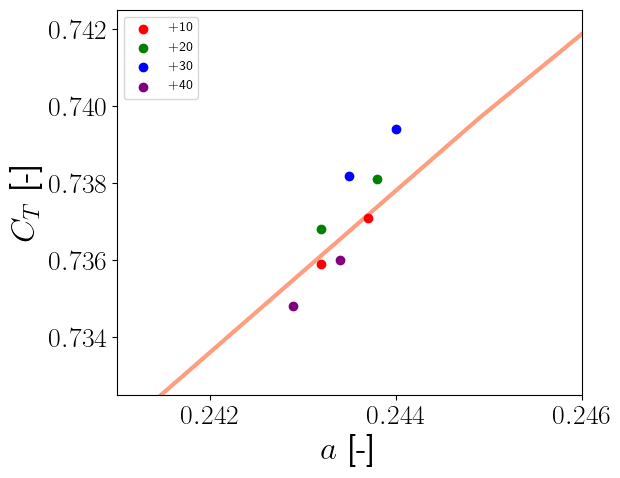

In [291]:
fig, ax = plt.subplots(figsize=(6, 5))

# up10_case0 = []
up10_case1 = [0.7975,0.2696]
up10_case2 = [0.7962,0.2690]
up10_case3 = [0.7371,0.2437]
up10_case4 = [0.7359,0.2432]

up20_case1 = [0.7979,0.2699]
up20_case2 = [0.7965,0.2692]
up20_case3 = [0.7381,0.2438]
up20_case4 = [0.7368,0.2432]

up30_case1 = [0.7958,0.2693]
up30_case2 = [0.7945,0.2687]
up30_case3 = [0.7394,0.2440]
up30_case4 = [0.7382,0.2435]

up40_case1 = [0.7963,0.2694]
up40_case2 = [0.7950,0.2688]
up40_case3 = [0.7360,0.2434]
up40_case4 = [0.7348,0.2429]

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,alpha = 0.5, zorder = 1)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,alpha=0.5,zorder=1)

ax.scatter(up10_case1[1],up10_case1[0], color='r', marker = 'o', label='+10%')
ax.scatter(up10_case2[1],up10_case2[0], color='r', marker = 'o')
ax.scatter(up10_case3[1],up10_case3[0], color='r', marker = 'o')
ax.scatter(up10_case4[1],up10_case4[0], color='r', marker = 'o')

ax.scatter(up20_case1[1],up20_case1[0], color='g', marker = 'o', label='+20%')
ax.scatter(up20_case2[1],up20_case2[0], color='g', marker = 'o')
ax.scatter(up20_case3[1],up20_case3[0], color='g', marker = 'o')
ax.scatter(up20_case4[1],up20_case4[0], color='g', marker = 'o')

ax.scatter(up30_case1[1],up30_case1[0], color='b', marker = 'o', label='+30%')
ax.scatter(up30_case2[1],up30_case2[0], color='b', marker = 'o')
ax.scatter(up30_case3[1],up30_case3[0], color='b', marker = 'o')
ax.scatter(up30_case4[1],up30_case4[0], color='b', marker = 'o')

ax.scatter(up40_case1[1],up40_case1[0], color='purple', marker = 'o', label='+40%')
ax.scatter(up40_case2[1],up40_case2[0], color='purple', marker = 'o')
ax.scatter(up40_case3[1],up40_case3[0], color='purple', marker = 'o')
ax.scatter(up40_case4[1],up40_case4[0], color='purple', marker = 'o')

ax.set_xlabel('$a$ [-]', fontsize=fontsize)
ax.set_ylabel('$C_T$ [-]', fontsize=fontsize)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylim([0.7325,0.7425])
ax.set_xlim([0.241,0.246])

plt.legend(title='$U_{\infty}$ [m/s]')

ax.legend()

# ax[0,0].axis('off')
# ax[0,1].axis('off')
# ax[0,3].axis('off')


# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)
plt.show()

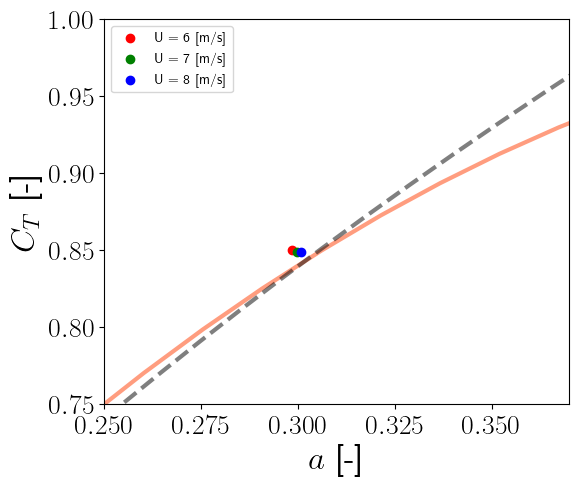

In [338]:
fig, ax = plt.subplots(figsize=(6, 5))

up10_case1 = [0.8498,0.2986]
up10_case2 = [0.8490,0.2998]
up10_case3 = [0.8484,0.3009]

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,alpha = 0.5, zorder = 1)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,alpha=0.5,zorder=1)

ax.scatter(up10_case1[1],up10_case1[0], color='r', marker = 'o', label='U = 6 [m/s]')
ax.scatter(up10_case2[1],up10_case2[0], color='g', marker = 'o', label='U = 7 [m/s]')
ax.scatter(up10_case3[1],up10_case3[0], color='b', marker = 'o', label='U = 8 [m/s]')

ax.set_xlabel('$a$ [-]', fontsize=fontsize)
ax.set_ylabel('$C_T$ [-]', fontsize=fontsize)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylim([0.75,1])
ax.set_xlim([0.25,0.37])

plt.legend(title='$U_{\infty}$ [m/s]')

ax.legend()

# ax[0,0].axis('off')
# ax[0,1].axis('off')
# ax[0,3].axis('off')


# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)
plt.show()